In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df = pd.read_csv('Dataset_ALDIMI_Merged.csv')

#  Selección de variables finales
vars_finales = [
    'Age', 'Smoking', 'Alcohol_Use', 'Obesity',
    'Family_History', 'Diet_Red_Meat', 'Diet_Salted_Processed',
    'Fruit_Veg_Intake', 'Physical_Activity', 'Air_Pollution',
    'Occupational_Hazards', 'BRCA_Mutation', 'H_Pylori_Infection',
    'Calcium_Intake', 'BMI', 'Overall_Risk_Score'
]

df_model = df[vars_finales].copy()
print("=== PUNTO 3.1 - Dataset final ===")
print("Dimensiones:", df_model.shape)
print("Variables:", list(df_model.columns))
print("\nPrimeras 5 filas:")
print(df_model.head())

=== PUNTO 3.1 - Dataset final ===
Dimensiones: (3000, 16)
Variables: ['Age', 'Smoking', 'Alcohol_Use', 'Obesity', 'Family_History', 'Diet_Red_Meat', 'Diet_Salted_Processed', 'Fruit_Veg_Intake', 'Physical_Activity', 'Air_Pollution', 'Occupational_Hazards', 'BRCA_Mutation', 'H_Pylori_Infection', 'Calcium_Intake', 'BMI', 'Overall_Risk_Score']

Primeras 5 filas:
   Age  Smoking  Alcohol_Use  Obesity  Family_History  Diet_Red_Meat  \
0   52       10            7        4               0             10   
1   73        5            4        8               0              7   
2   70        3            0        2               0              4   
3   64        6            3        4               0              4   
4   60        4            8        4               1              1   

   Diet_Salted_Processed  Fruit_Veg_Intake  Physical_Activity  Air_Pollution  \
0                      3                10                  8             10   
1                      4                 3    

In [24]:
# Análisis estadístico profundo (tendencia central y dispersión)
print("\n=== MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN ===")
estadisticos = df_model.describe().T
estadisticos['varianza'] = df_model.var()
estadisticos['desviacion'] = df_model.std()
print(estadisticos.round(4))


=== MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN ===
                        count     mean      std      min      25%      50%  \
Age                    3000.0  63.5403  10.1765  29.0000  57.0000  64.0000   
Smoking                3000.0   5.1597   3.3348   0.0000   2.0000   5.0000   
Alcohol_Use            3000.0   5.0167   3.3129   0.0000   2.0000   5.0000   
Obesity                3000.0   5.9773   3.0878   0.0000   4.0000   6.0000   
Family_History         3000.0   0.1873   0.3902   0.0000   0.0000   0.0000   
Diet_Red_Meat          3000.0   5.2233   3.1761   0.0000   3.0000   5.0000   
Diet_Salted_Processed  3000.0   4.5327   3.0836   0.0000   2.0000   4.0000   
Fruit_Veg_Intake       3000.0   4.9537   3.0443   0.0000   3.0000   5.0000   
Physical_Activity      3000.0   4.0173   3.0419   0.0000   1.0000   4.0000   
Air_Pollution          3000.0   5.3023   3.2029   0.0000   3.0000   5.0000   
Occupational_Hazards   3000.0   5.0083   3.2041   0.0000   2.0000   5.0000   
BRCA_Mutation

In [25]:
#  Calidad de datos: nulos e imputación (con media)
print("\n=== NULOS ANTES DE IMPUTACIÓN ===")
print(df_model.isnull().sum())

# Imputación con media (todas son numéricas)
df_model_imputed = df_model.fillna(df_model.mean())

print("\n=== NULOS DESPUÉS DE IMPUTACIÓN (media) ===")
print(df_model_imputed.isnull().sum().sum(), "nulos restantes")


=== NULOS ANTES DE IMPUTACIÓN ===
Age                      0
Smoking                  0
Alcohol_Use              0
Obesity                  0
Family_History           0
Diet_Red_Meat            0
Diet_Salted_Processed    0
Fruit_Veg_Intake         0
Physical_Activity        0
Air_Pollution            0
Occupational_Hazards     0
BRCA_Mutation            0
H_Pylori_Infection       0
Calcium_Intake           0
BMI                      0
Overall_Risk_Score       0
dtype: int64

=== NULOS DESPUÉS DE IMPUTACIÓN (media) ===
0 nulos restantes



=== DETECCIÓN DE OUTLIERS ===


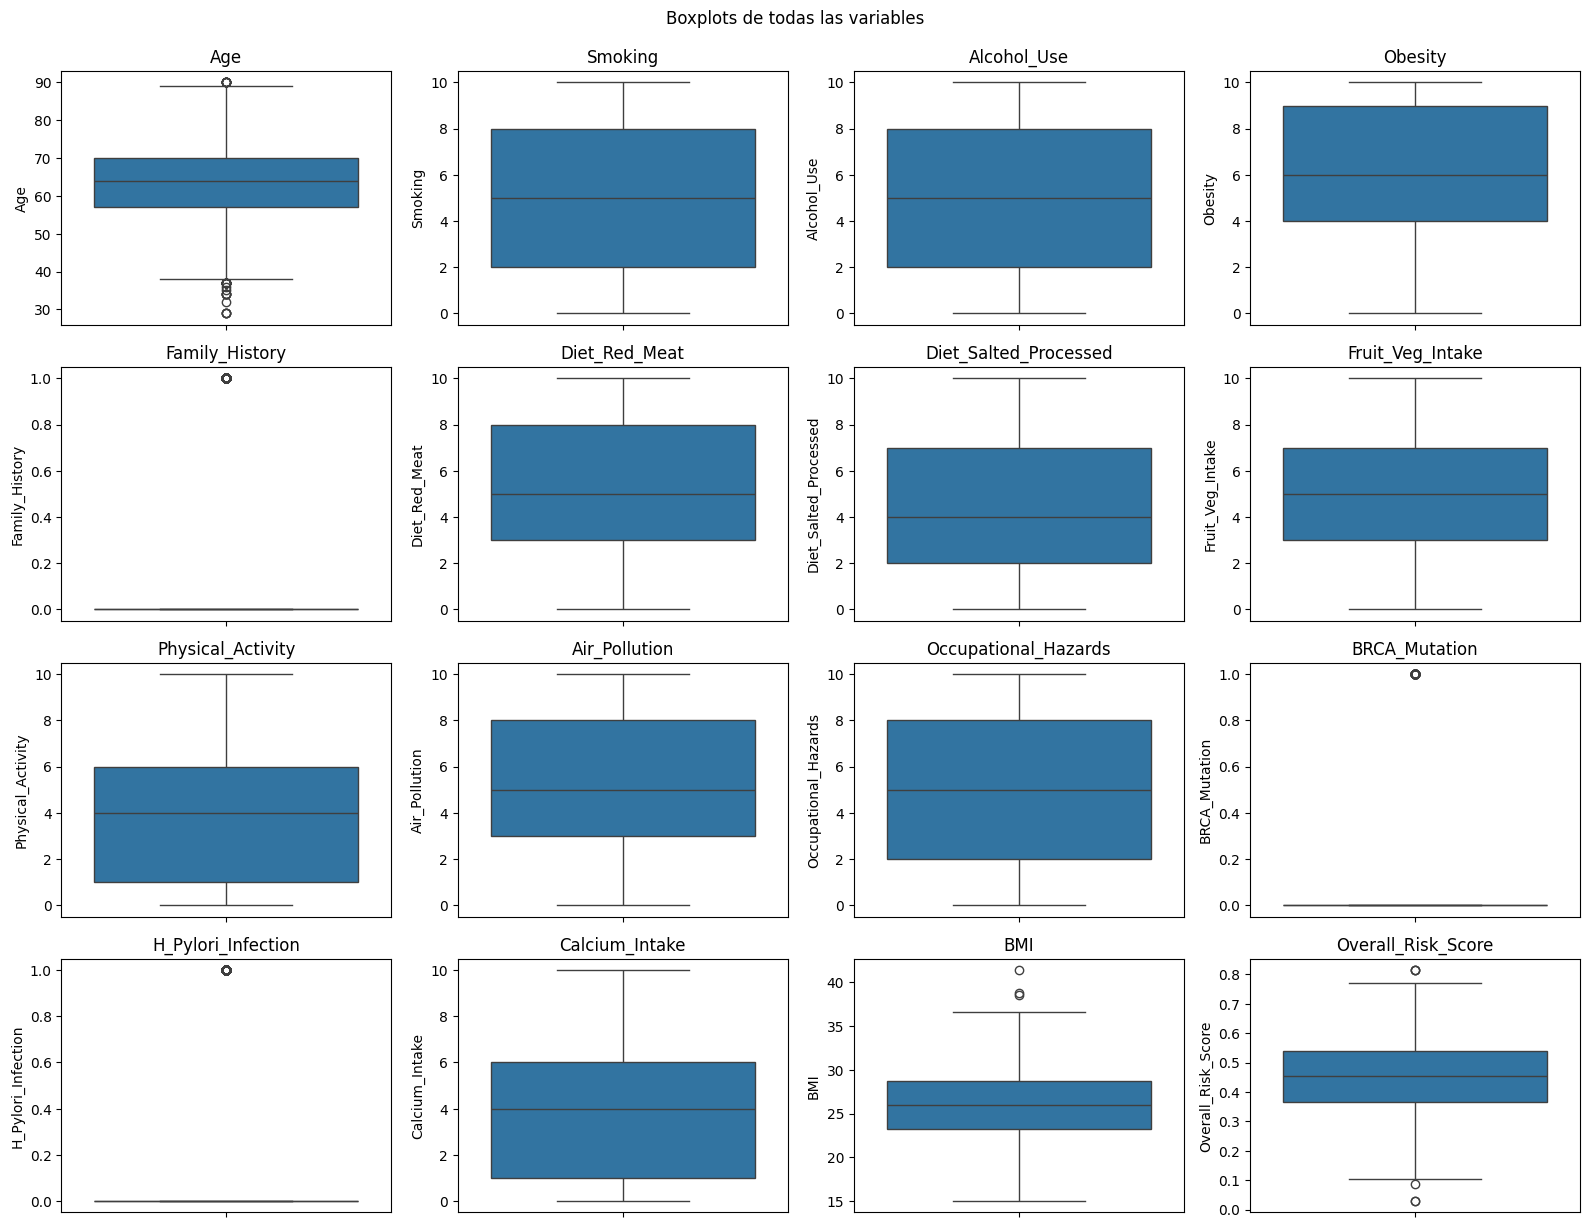

Outliers por variable (|z| > 3):
  Age: 5 outliers
  Smoking: 0 outliers
  Alcohol_Use: 0 outliers
  Obesity: 0 outliers
  Family_History: 0 outliers
  Diet_Red_Meat: 0 outliers
  Diet_Salted_Processed: 0 outliers
  Fruit_Veg_Intake: 0 outliers
  Physical_Activity: 0 outliers
  Air_Pollution: 0 outliers
  Occupational_Hazards: 0 outliers
  BRCA_Mutation: 81 outliers
  H_Pylori_Infection: 0 outliers
  Calcium_Intake: 0 outliers
  BMI: 3 outliers
  Overall_Risk_Score: 2 outliers


In [26]:
#  Detección de outliers con Boxplots y Z-score
print("\n=== DETECCIÓN DE OUTLIERS ===")

# Boxplots
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(vars_finales):
    sns.boxplot(y=df_model_imputed[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.suptitle("Boxplots de todas las variables", y=1.02)
plt.show()

# Z-score
from scipy import stats
z_scores = np.abs(stats.zscore(df_model_imputed))
outliers_count = (z_scores > 3).sum(axis=0)
print("Outliers por variable (|z| > 3):")
for col, count in zip(vars_finales, outliers_count):
    print(f"  {col}: {count} outliers")


=== MATRIZ DE CORRELACIÓN (vs target) ===
Overall_Risk_Score       1.000000
Air_Pollution            0.490084
Smoking                  0.431812
Alcohol_Use              0.410504
Diet_Salted_Processed    0.360162
Occupational_Hazards     0.337496
Diet_Red_Meat            0.275309
Obesity                  0.238195
BMI                      0.066902
Calcium_Intake           0.034551
Family_History           0.029765
BRCA_Mutation            0.029614
H_Pylori_Infection       0.028031
Physical_Activity        0.022091
Age                     -0.040873
Fruit_Veg_Intake        -0.130463
Name: Overall_Risk_Score, dtype: float64

=== MATRIZ DE COVARIANZA (primeras 5 filas) ===
                       Age    Smoking  Alcohol_Use   Obesity  Family_History
Age             103.560894   0.440207    -1.123047  0.512085        0.038457
Smoking           0.440207  11.121214     1.635217 -0.749631       -0.014916
Alcohol_Use      -1.123047   1.635217    10.975381  0.222785        0.008214
Obesity        

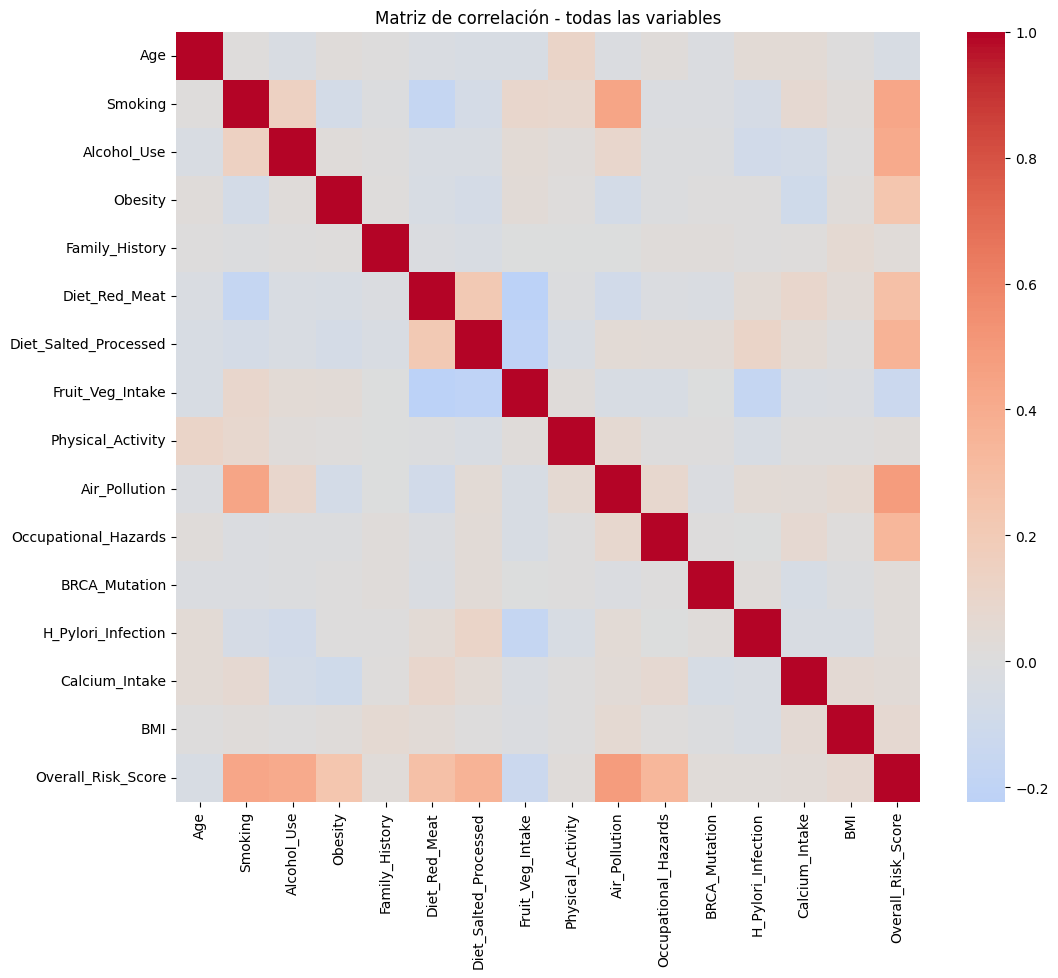

In [27]:
#  Análisis multivariado
print("\n=== MATRIZ DE CORRELACIÓN (vs target) ===")
corr_matrix = df_model_imputed.corr()
target_corr = corr_matrix['Overall_Risk_Score'].sort_values(ascending=False)
print(target_corr)

print("\n=== MATRIZ DE COVARIANZA (primeras 5 filas) ===")
cov_matrix = df_model_imputed.cov()
print(cov_matrix.iloc[:5, :5])

# Heatmap de correlación
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title("Matriz de correlación - todas las variables")
plt.show()

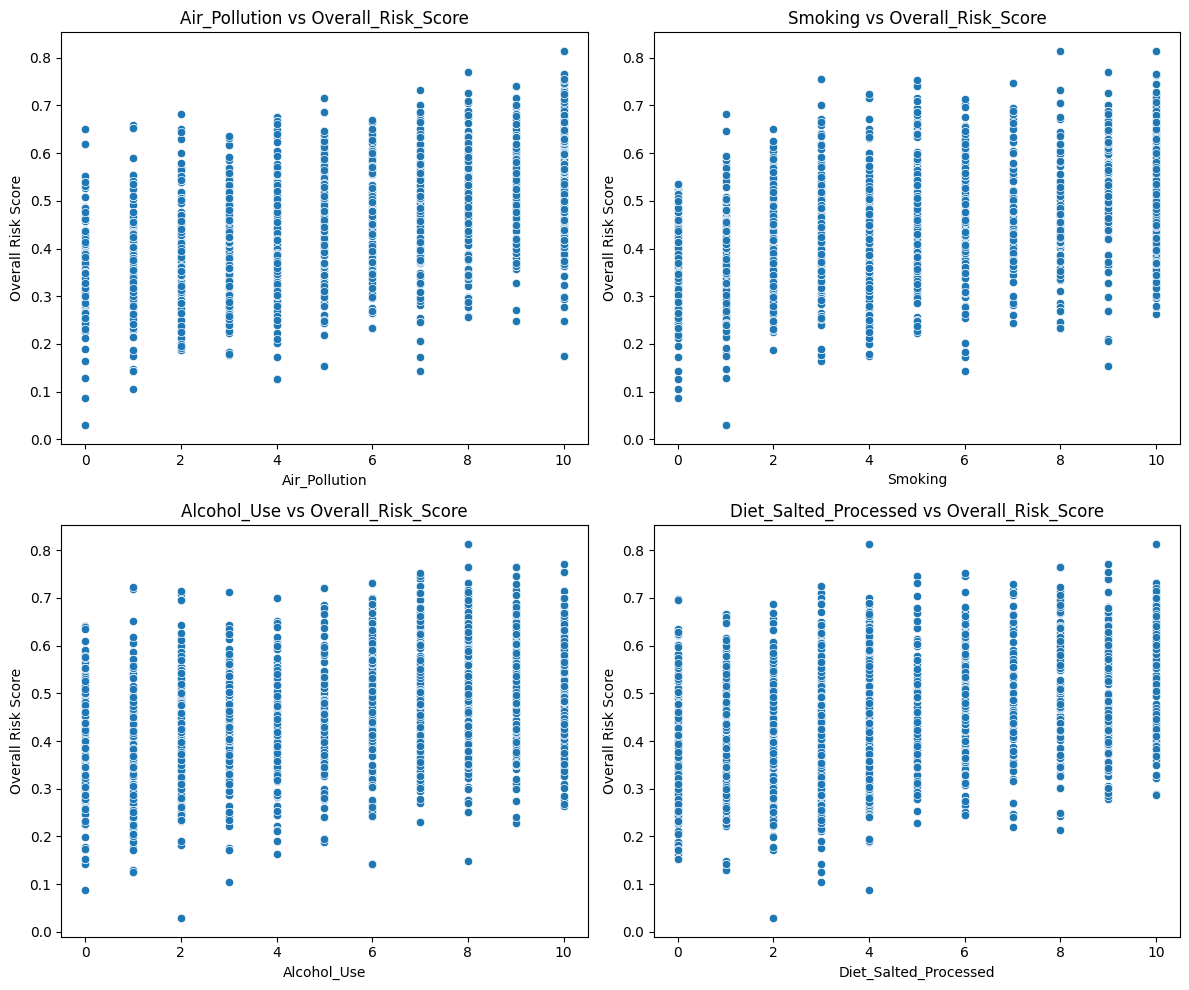

In [28]:
# Gráficos de dispersión (predictoras vs objetivo)

# Seleccionamos las 4 predictoras con mayor correlación (absoluta) con el target
top_features = target_corr.drop('Overall_Risk_Score').abs().sort_values(ascending=False).head(4).index

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, col in enumerate(top_features):
    sns.scatterplot(x=df_model_imputed[col],
                    y=df_model_imputed['Overall_Risk_Score'],
                    ax=axes[i])
    axes[i].set_title(f'{col} vs Overall_Risk_Score')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Overall Risk Score')
plt.tight_layout()
plt.show()

In [29]:
#Preparar datos para MLPClassifier si lo necesitas después
print("\n=== PREPARACIÓN PARA RED NEURONAL (MLPClassifier) ===")
X = df_model_imputed.drop('Overall_Risk_Score', axis=1)
y = df_model_imputed['Overall_Risk_Score']

# Convertir target a categórico si es necesario (ej. Low/Medium/High)
# En tu dataset ya existe 'Risk_Level', pero si usamos Overall_Risk_Score, debemos discretizarlo
# Ejemplo: dividir en 3 niveles (bajo, medio, alto)
y_discretizado = pd.cut(y, bins=3, labels=['Low', 'Medium', 'High'])

# Escalar características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# División en train/test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_discretizado, test_size=0.2, random_state=42)

print("Tamaño de entrenamiento:", X_train.shape)
print("Tamaño de prueba:", X_test.shape)

# Entrenar red neuronal (ejemplo rápido)
mlp = MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=500, random_state=42)
mlp.fit(X_train, y_train)

# Predicciones y evaluación
y_pred = mlp.predict(X_test)
print("\n=== REPORTE DE CLASIFICACIÓN (MLP) ===")
print(classification_report(y_test, y_pred))


=== PREPARACIÓN PARA RED NEURONAL (MLPClassifier) ===
Tamaño de entrenamiento: (2400, 15)
Tamaño de prueba: (600, 15)

=== REPORTE DE CLASIFICACIÓN (MLP) ===
              precision    recall  f1-score   support

        High       0.94      0.83      0.88       122
         Low       0.81      0.91      0.86        56
      Medium       0.94      0.95      0.95       422

    accuracy                           0.93       600
   macro avg       0.89      0.90      0.89       600
weighted avg       0.93      0.93      0.92       600



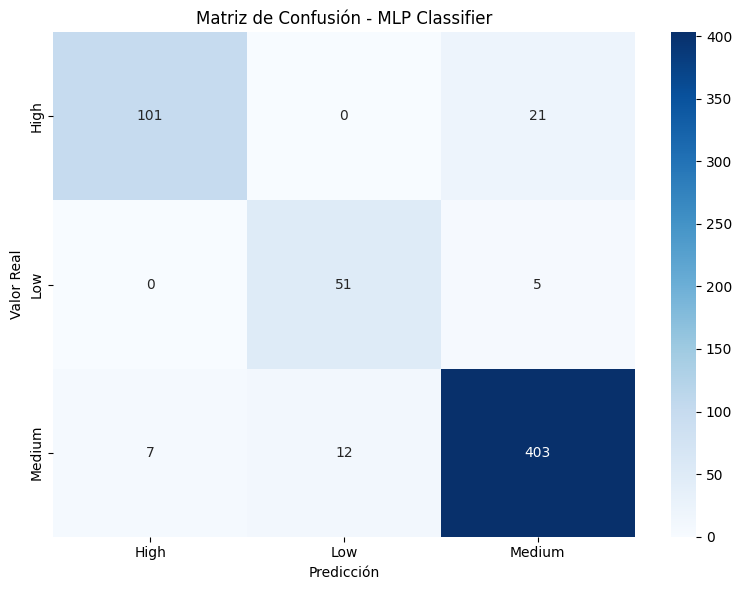

In [30]:
# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Graficar matriz de confusión como heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=mlp.classes_,
            yticklabels=mlp.classes_)
plt.title('Matriz de Confusión - MLP Classifier')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()